<a href="https://colab.research.google.com/github/vdlucas-queiroz/CadImobi/blob/main/COTIA_prompt_coord_com_curva.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# RECONSTRUÇÃO DE GEOMETRIA DE MEMORIAL DESCRITIVO POR MEIO DE COORDENADAS
# Vinicius D'Lucas Bezerra e Queiroz

In [ ]:
!pip install adjustText
!pip install simplekml
!pip install folium pyproj
!pip cache purge
!pip install -U google-genai


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 2.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for simplekml: filename=simplekml-1.3.6-py3-none-any.whl size=65860 sha256=9d13dfd379d840d8aba122a6104c04e116c9c9420018b0253cfbbf4caea8b9c8
  Stored in directory: /root/.cache/pip/wheels/83/ee/f2/65cecfd948f1429ead035fd6d56bc6bd6574a636ddc4d65cbd
Successfully built simplekml
Files removed: 11
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.1/259.1 kB 20.5 MB/s eta 0:00:00
  Attempting uninstall: google-auth
    Found existing installation: google-auth 2.49.0
    Uninstalling google-auth-2.49.0:
      Successfully uninstalled google-auth-2.49.0
  Attempting uninstall: google-genai
    Found existing installation: google-genai 2.12.1
    Uninstalling google-genai-2.12.1:
      Successfully uninstall

In [ ]:
import pandas as pd
import numpy as np
from shapely.geometry import Polygon
import matplotlib.pyplot as plt
from adjustText import adjust_text
import folium
from pyproj import Transformer

from google.colab import files
from google import genai
from google.colab import userdata
import re
import time
import json


In [ ]:
# 1. Configuração da API
try:
    api_key = userdata.get('GEMINI_API_KEY')
    client = genai.Client(api_key=api_key)
    print("API Configurada com sucesso!")
except Exception as e:
    print("ERRO: Configure o Secret 'GEMINI_API_KEY' no menu lateral.")

def obter_tabela_via_ai(caminho_arquivo, prompt):
    """
    Envia o arquivo (PDF ou Imagem) diretamente para o Gemini.
    A IA faz o OCR (leitura de imagem) e a extração dos dados em um único passo.
    """

    # Busca o nome correto do modelo disponível
    nome_modelo = 'gemini-2.5-flash' # Versão estável e rápida

    # 2. Upload do arquivo para a API do Google (suporta PDF e Imagens)
    print(f"Fazendo upload do arquivo: {caminho_arquivo}...")
    sample_file = client.files.upload(file=caminho_arquivo)

    # Aguarda o processamento do arquivo pelo Google
    while sample_file.state.name == "PROCESSING":
        print(".", end="")
        time.sleep(2)
        sample_file = client.files.get(name=sample_file.name)

    # 3. Prompt especializado (ajustado para ler páginas 3 a 7) #AJUSTAR O PROMPT

    print("Gemini analisando o documento (OCR + Extração)...")
    response = client.models.generate_content(
        model=nome_modelo,
        contents=[sample_file, prompt],
        config={
            "response_mime_type": "application/json"
        }
    )

  # 4. Limpeza (opcional, mas boa prática)
    client.files.delete(name=sample_file.name)

    return response.text


API Configurada com sucesso!


In [ ]:
# Funções

# Conversão de gms para decimal

def gms_to_decimal(az):
    g, rest = az.split("°")
    m, s = rest.replace('"','').split("'")
    return float(g) + float(m)/60 + float(s)/3600

def plot_vertices_folium(
    coords,
    epsg_utm="EPSG:31983",
    zoom_start=18
):
    """
    Plota vértices e polígono em um mapa Folium.
    """

    from pyproj import Transformer
    import folium

    # Transformador UTM -> WGS84
    transformer = Transformer.from_crs(
        epsg_utm,
        "EPSG:4326",
        always_xy=True
    )

    # Conversão das coordenadas
    coords_geo = [transformer.transform(x, y) for x, y in coords]

    # Centro do mapa
    lon_c = sum(pt[0] for pt in coords_geo) / len(coords_geo)
    lat_c = sum(pt[1] for pt in coords_geo) / len(coords_geo)

    m = folium.Map(
        location=[lat_c, lon_c],
        zoom_start=zoom_start,
        tiles="OpenStreetMap"
    )

    # Polígono (AMARELO)
    folium.Polygon(
        locations=[(lat, lon) for lon, lat in coords_geo],
        color="yellow",
        weight=2,
        fill=True,
        fill_color="yellow",
        fill_opacity=0.3,
        tooltip="Polígono reconstruído"
    ).add_to(m)

    # Vértices (PONTOS BRANCOS)
    for i, ((x, y), (lon, lat)) in enumerate(zip(coords, coords_geo)):
        nome = f"P{i+1:02d}"

        # Destaque do ponto inicial
        radius = 7 if i == 0 else 5

        folium.CircleMarker(
            location=[lat, lon],
            radius=radius,
            color="white",
            fill=True,
            fill_color="white",
            fill_opacity=1,
            popup=(
                f"<b>{nome}</b><br>"
                f"UTM 23S (SIRGAS2000)<br>"
                f"X = {x:.3f} m<br>"
                f"Y = {y:.3f} m"
            )
        ).add_to(m)

        # Rótulo fixo (FONTE BRANCA)
        folium.Marker(
            location=[lat, lon],
            icon=folium.DivIcon(
                html=f"""
                <div style="
                    font-size:10px;
                    font-weight:bold;
                    color:white;
                    text-shadow: 1px 1px 2px black;
                    transform: translate(6px, -6px);
                ">
                    {nome}
                </div>
                """
            )
        ).add_to(m)

    # Camada de imagem de satélite
    folium.TileLayer(
        "Esri.WorldImagery",
        name="Imagem de Satélite (ESRI)",
        control=True
    ).add_to(m)

    folium.LayerControl().add_to(m)

    return m




In [ ]:
def interpolar_curva_memorial(p_inicio, p_destino, raio, desenvolvimento,
                              sentido='direita', num_pontos=20, tol_corda=0.05):
    p1 = np.asarray(p_inicio, dtype=float)
    p2 = np.asarray(p_destino, dtype=float)
    raio = float(raio); desenvolvimento = float(desenvolvimento)

    if raio <= 0:
        raise ValueError(f"raio inválido ({raio}); pontos colapsariam no centro.")
    if desenvolvimento <= 0:
        raise ValueError(f"desenvolvimento inválido ({desenvolvimento}).")
    corda = float(np.linalg.norm(p2 - p1))
    if corda < 1e-9:
        raise ValueError("p_inicio ~ p_destino (corda nula); destino == vértice anterior?")
    if corda > 2*raio + tol_corda:
        raise ValueError(f"corda ({corda:.3f}) > 2R ({2*raio:.3f}); raio incompatível com a corda.")

    delta = desenvolvimento / raio                       # ângulo central — agora usado
    corda_teorica = 2*raio*np.sin(delta/2)               # QA de coerência do memorial
    if abs(corda_teorica - corda) > tol_corda:
        print(f"[AVISO] corda medida {corda:.3f} m x teórica {corda_teorica:.3f} m "
              f"(Δ={corda-corda_teorica:+.3f} m) — memorial possivelmente inconsistente.")

    ang_corda = np.arctan2((p2-p1)[1], (p2-p1)[0])
    h = np.sqrt(max(0.0, raio**2 - (corda/2)**2))
    mid = (p1 + p2)/2
    lado = -1 if sentido == 'direita' else 1             # centro à direita/esquerda da corda
    ang_perp = ang_corda + lado*np.pi/2
    centro = mid + h*np.array([np.cos(ang_perp), np.sin(ang_perp)])

    R_fit = float(np.linalg.norm(p1 - centro))           # raio ajustado -> fecha exato em p1/p2
    ang_start = np.arctan2(p1[1]-centro[1], p1[0]-centro[0])
    s = -1 if sentido == 'direita' else 1                # varredura horária/anti-horária
    theta = ang_start + s*np.linspace(0.0, delta, num_pontos)
    return [[centro[0] + R_fit*np.cos(t), centro[1] + R_fit*np.sin(t)] for t in theta]

In [ ]:
# interpolar na mão
pontos = interpolar_curva_memorial([308514.8700, 7388773.5784], [308520.9421, 7388778.2775], 4.587, 9.097, sentido='direita', num_pontos=10)

In [ ]:
pontos = pd.DataFrame(pontos, columns=['E', 'N'])
pontos

,E,N
0,308514.870000,7.388774e+06
1,308514.900979,7.388775e+06
2,308515.151612,7.388776e+06
3,308515.609778,7.388776e+06
4,308516.253318,7.388777e+06
5,308517.051105,7.388778e+06
6,308517.964554,7.388778e+06
7,308518.949487,7.388779e+06
8,308519.958266,7.388779e+06
9,308520.942100,7.388778e+06


In [ ]:
# Exportando txt estilo geopixel
file_name = "pontos_curva.txt"
pontos[['E', 'N']].to_csv(file_name, sep=' ', header=False, index=False)
files.download(file_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

1. EXTRAÇÃO DAS INFORMAÇÕES DO MEMORIAL DESCRITIVO

In [ ]:
prompt = """
Você é um especialista em georreferenciamento de imoveis e topografia.
Analise a imagem.

Extraia todas coordenadas os pontos (Ponto, Coordenada Este e Coorenada Norte) do memorial descritivo.
Mesmo que o documento seja uma imagem digitalizada, faça o OCR e extraia os dados na forma a seguir:

Extraia as informações sobre as curvas e como resultado:
[
  {
    "ponto_origem": "P01",
    "ponto_destino": "P02",
    "coordenadas_destino": {"E": 304720.15, "N": 7508150.80},
    "tipo_segmento": "RETA",
    "parametros_curva": null
  },
  {
    "ponto_origem": "P02",
    "ponto_destino": "P03",
    "coordenadas_destino": {"E": 304810.00, "N": 7508100.00},
    "tipo_segmento": "CURVA",
    "parametros_curva": {
      "sentido": "direita",
      "raio": 131.94,
      "desenvolvimento": 99.12,
      "angulo_deflexao": {
        "graus": 166,
        "minutos": 28,
        "segundos": 17
      }
    }
  }
]


Regras:
0. Deve conter preenchido todos os elementos do exemplo
1. Retorne APENAS o código da lista, nada de explicações ou Markdown.
2. O azimute deve ser string com símbolos de graus, minutos e segundos.
3. A distância deve ser float (use ponto para decimais).
4. Não pule nenhum vértice. Verifique do ponto 01 até o fechamento.
"""


In [ ]:
# --- EXECUÇÃO --- PROMPT 1
#arquivo = "/content/matricula.pdf" # Pode ser .pdf, .png, .jpg ou .jpeg
arquivo = '/content/20260819_142043.jpg'

try:
    resultado_bruto = obter_tabela_via_ai(arquivo, prompt)

    # Limpeza de Markdown
    codigo_limpo = re.sub(r'```json|```python|```', '', resultado_bruto).strip()

    # Executa o código para gerar a variável 'data'
    data = json.loads(codigo_limpo)

    print("\n--- SUCESSO ---")
    print(f"Total de ponto: {len(data)}")
    print("Exemplo dos primeiros dados:", data[:5])

except Exception as e:
    print(f"\nErro no processamento: {e}")

Fazendo upload do arquivo: /content/20260819_142043.jpg...


Gemini analisando o documento (OCR + Extração)...

--- SUCESSO ---
Total de ponto: 30
Exemplo dos primeiros dados: [{'ponto_origem': 'A', 'ponto_destino': 'B', 'coordenadas_destino': {'E': 294310.962, 'N': 7378419.043}, 'tipo_segmento': 'RETA', 'parametros_curva': None}, {'ponto_origem': 'B', 'ponto_destino': 'C', 'coordenadas_destino': {'E': 294303.973, 'N': 7378419.52}, 'tipo_segmento': 'RETA', 'parametros_curva': None}, {'ponto_origem': 'C', 'ponto_destino': 'D', 'coordenadas_destino': {'E': 294292.572, 'N': 7378407.63}, 'tipo_segmento': 'RETA', 'parametros_curva': None}, {'ponto_origem': 'D', 'ponto_destino': 'E', 'coordenadas_destino': {'E': 294285.45, 'N': 7378402.302}, 'tipo_segmento': 'RETA', 'parametros_curva': None}, {'ponto_origem': 'E', 'ponto_destino': 'F', 'coordenadas_destino': {'E': 294278.443, 'N': 7378398.681}, 'tipo_segmento': 'RETA', 'parametros_curva': None}]


In [ ]:
# Confira o resultado
data

[{'ponto_origem': 'A',
  'ponto_destino': 'B',
  'coordenadas_destino': {'E': 294310.962, 'N': 7378419.043},
  'tipo_segmento': 'RETA',
  'parametros_curva': None},
 {'ponto_origem': 'B',
  'ponto_destino': 'C',
  'coordenadas_destino': {'E': 294303.973, 'N': 7378419.52},
  'tipo_segmento': 'RETA',
  'parametros_curva': None},
 {'ponto_origem': 'C',
  'ponto_destino': 'D',
  'coordenadas_destino': {'E': 294292.572, 'N': 7378407.63},
  'tipo_segmento': 'RETA',
  'parametros_curva': None},
 {'ponto_origem': 'D',
  'ponto_destino': 'E',
  'coordenadas_destino': {'E': 294285.45, 'N': 7378402.302},
  'tipo_segmento': 'RETA',
  'parametros_curva': None},
 {'ponto_origem': 'E',
  'ponto_destino': 'F',
  'coordenadas_destino': {'E': 294278.443, 'N': 7378398.681},
  'tipo_segmento': 'RETA',
  'parametros_curva': None},
 {'ponto_origem': 'F',
  'ponto_destino': 'G',
  'coordenadas_destino': {'E': 294270.239, 'N': 7378398.316},
  'tipo_segmento': 'RETA',
  'parametros_curva': None},
 {'ponto_orig

In [ ]:
# 1. Inicializamos a lista com a coordenada do primeiro ponto de origem
# (Ajuste as chaves conforme o seu JSON de extração)
primeiro_ponto = [294313.060, 7378420.539]
lista_final_geometria = [primeiro_ponto]

for trecho in data:
    # Definimos o ponto final do segmento atual
    p_fim = [trecho['coordenadas_destino']['E'], trecho['coordenadas_destino']['N']]

    if trecho['tipo_segmento'] == 'CURVA':
        # O ponto de início da curva é o último ponto adicionado na lista_final
        p_ini = lista_final_geometria[-1]

        # Extraímos os parâmetros do objeto 'parametros_curva'
        params = trecho['parametros_curva']

        # Chamamos a função atualizada (interpolar_curva_memorial)
        # Note que a função já retorna uma lista de pontos incluindo o p_fim
        pontos_da_curva = interpolar_curva_memorial(
            p_inicio=p_ini,
            p_destino=p_fim,
            raio=params['raio'],
            desenvolvimento=params['desenvolvimento'],
            sentido=params['sentido'],
            num_pontos=20 # Você pode aumentar para curvas mais suaves
        )

        # Removemos o primeiro ponto da interpolação para não duplicar com o p_ini já existente
        lista_final_geometria.extend(pontos_da_curva[1:])

    else:
        # Se for RETA, apenas adicionamos o ponto de destino
        lista_final_geometria.append(p_fim)


ValueError: p_inicio ~ p_destino (corda nula); destino == vértice anterior?

In [ ]:
lista_final_geometria

[[294313.06, 7378420.539],
 [294310.962, 7378419.043],
 [294303.973, 7378419.52],
 [294292.572, 7378407.63],
 [294285.45, 7378402.302],
 [294278.443, 7378398.681],
 [294270.239, 7378398.316],
 [294266.963, 7378394.724],
 [294260.662, 7378387.17],
 [294254.128, 7378380.886],
 [294253.699, 7378376.999],
 [294250.144, 7378371.653],
 [294241.302, 7378366.193],
 [294236.718, 7378364.06],
 [294230.336, 7378361.842],
 [294226.628, 7378362.552],
 [294226.425, 7378365.642],
 [294222.105, 7378372.917],
 [294219.247, 7378375.293],
 [294217.265, 7378377.57],
 [294215.077, 7378377.491],
 [294210.193, 7378375.961],
 [294206.121, 7378378.387],
 [294203.948, 7378376.017],
 [294201.576, 7378374.786],
 [294198.545, 7378371.747],
 [294195.767, 7378372.623],
 [294218.676, 7378471.884],
 [294241.21, 7378475.574],
 [np.float64(294241.21), np.float64(7378475.574)],
 [np.float64(294241.21), np.float64(7378475.574)],
 [np.float64(294241.21), np.float64(7378475.574)],
 [np.float64(294241.21), np.float64(7378475

In [ ]:
# 1. Transformar a lista de pontos em um DataFrame comum do Pandas
# Cada ponto na lista é [E, N]
df = pd.DataFrame(lista_final_geometria, columns=['E', 'N'])


In [ ]:
df

,E,N
0,294313.060,7378420.539
1,294310.962,7378419.043
2,294303.973,7378419.520
3,294292.572,7378407.630
4,294285.450,7378402.302
5,294278.443,7378398.681
6,294270.239,7378398.316
7,294266.963,7378394.724
8,294260.662,7378387.170
9,294254.128,7378380.886


In [ ]:
# Exportação da tabela de pontos corrigida
file_name = "area7.csv"
df.to_csv(file_name, index=False)
files.download(file_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

2. CÁLCULO PARA GERAÇÃO DE MEMORIAL DESCRITIVO

In [ ]:
# CASO JÁ TENHA GERADO O RESULTADO ANTERIORMENTE, IMPORTE O CSV AQUI

df = pd.read_csv("pontos.csv")
df

In [ ]:
# Se já estiver em coord UTM
coords = []
for dx, dy in zip(df["E"], df["N"]):
    coords.append((dx, dy))

vertices = pd.DataFrame(coords, columns=["E","N"])
vertices["Vertice"] = [f"P{i+1:02d}" for i in range(len(vertices))]
xv, yv = zip(*coords)


In [ ]:
# Exportando
file_name = "area9.txt"
vertices[['E', 'N']].to_csv(file_name, sep=' ', header=False, index=False)
files.download(file_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

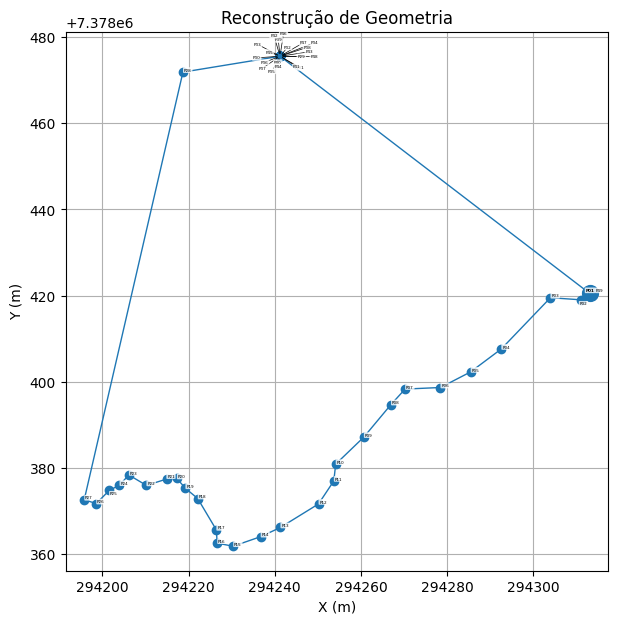

In [ ]:
# PLOTAGEM OS RESULTADOS SEM MAPA BASE

plt.figure(figsize=(7,7))
plt.plot(xv, yv, marker="o", linewidth=1)

texts = []

for i, (x, y) in enumerate(coords):
    label = f"P{i+1:02d}"

    if i == 0:
        plt.scatter(x, y, s=130, zorder=5)
        weight = "bold"
    else:
        weight = "normal"

    txt = plt.text(
        x, y, label,
        fontsize=3,
        fontweight=weight,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.8),
        zorder=6
    )
    texts.append(txt)

# Ajuste automático (repulsão)
adjust_text(
    texts,
    x=xv,
    y=yv,
    expand_points=(1.5, 1.5),
    expand_text=(1.4, 1.4),
    force_points=0.4,
    force_text=0.8,
    arrowprops=dict(arrowstyle="-", lw=0.5)
)

plt.axis("equal")
plt.grid(True)
plt.title("Reconstrução de Geometria")
plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.show()


In [ ]:
# CÁLCULO DE ÁREA PELO MÉTODO ANALÍTICO DE GAUSS
coords_array = np.array(coords)

x = coords_array[:, 0]
y = coords_array[:, 1]

area_m2 = 0.5 * abs(
    np.dot(x, np.roll(y, -1)) - np.dot(y, np.roll(x, -1))
)

area_ha = area_m2 / 10_000

print(f"Área (Shoelace): {area_m2:,.2f} m² ({area_ha:.4f} ha)")


Área (Shoelace): 2,035.88 m² (0.2036 ha)


In [ ]:
# PLOTAGEM COM MAPA BASE
m = plot_vertices_folium(coords)
m

In [ ]:
import simplekml
from pyproj import Transformer

# EXPORTAÇÃO DA GEOMETRIA

# Transformação: SIRGAS2000 / UTM 23S -> WGS84
transformer = Transformer.from_crs(
    "EPSG:31983",  # SIRGAS2000 / UTM 23S
    "EPSG:4326",   # WGS84 (obrigatório para KML)
    always_xy=True
)

coords_geo = [transformer.transform(x, y) for x, y in coords]

kml = simplekml.Kml()

# Documento com descrição técnica
kml.document.name = "Vértices – Memorial Descritivo"
kml.document.description = (
    "Geometria originalmente calculada em:\n"
    "SIRGAS 2000 / UTM Zona 23S (EPSG:31983)\n\n"
    "Conversão para WGS84 (EPSG:4326) realizada "
    "exclusivamente para compatibilidade com o formato KML."
)

for i, ((x, y), (lon, lat)) in enumerate(zip(coords, coords_geo)):
    nome = f"P{i+1:02d}"

    pnt = kml.newpoint(
        name=nome,
        coords=[(lon, lat)]
    )

    pnt.description = (
        f"Vértice {nome}\n\n"
        f"SIRGAS2000 / UTM 23S:\n"
        f"X = {x:.3f} m\n"
        f"Y = {y:.3f} m\n\n"
        f"WGS84 (KML):\n"
        f"Lon = {lon:.8f}\n"
        f"Lat = {lat:.8f}"
    )

    pnt.style.iconstyle.scale = 0.9
    pnt.style.iconstyle.icon.href = (
        "http://maps.google.com/mapfiles/kml/shapes/placemark_circle.png"
    )

output_kml = "/content/vertices_sirgas2000_utm23S.kml"
kml.save(output_kml)

output_kml


'/content/vertices_sirgas2000_utm23S.kml'

3. GERAÇÃO DE MAPAS

In [ ]:
!pip install geopandas matplotlib contextily shapely matplotlib-scalebar cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 107.3 MB/s eta 0:00:00


In [ ]:
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Polygon
import contextily as ctx
from matplotlib_scalebar.scalebar import ScaleBar # Importação da barra de escala

def gerar_mapa_profissional(data_coords, crs, nome_imovel):
    # --- 1. CONFIGURAÇÃO DOS DADOS ---
    gdf = gpd.GeoDataFrame(index=[0], crs=crs, geometry=[Polygon(data_coords)])

    # --- 2. CRIAÇÃO DA FIGURA ---
    fig = plt.figure(figsize=(16, 9))
    gs = fig.add_gridspec(1, 2, width_ratios=[4, 1.2], wspace=0.05)

    ax_mapa = fig.add_subplot(gs[0])
    ax_info = fig.add_subplot(gs[1])
    ax_info.axis('off')

    # --- 3. DESENHO DO MAPA ---
    gdf.plot(ax=ax_mapa, facecolor='none', edgecolor='yellow', linewidth=2, zorder=10)

    ctx.add_basemap(ax_mapa, source=ctx.providers.Esri.WorldImagery, crs=gdf.crs)
    ctx.add_basemap(ax_mapa, source=ctx.providers.CartoDB.PositronOnlyLabels, crs=gdf.crs, zorder=11)

    # --- 4. INSERÇÃO DO NORTE ---
    # Colocamos o Norte no canto superior direito do mapa
    x_n, y_n, largura_n = 0.95, 0.95, 0.03
    ax_mapa.annotate('N', xy=(x_n, y_n), xytext=(x_n, y_n-0.08),
                     arrowprops=dict(facecolor='white', width=4, headwidth=12),
                     ha='center', va='center', fontsize=20, color='white',
                     fontweight='bold', xycoords='axes fraction')

    # --- 5. INSERÇÃO DA BARRA DE ESCALA ---
    # Como o CRS é UTM (metros), a escala 1:1 funciona perfeitamente
    scalebar = ScaleBar(1, units="m", location="lower left",
                        box_alpha=0.5, color="white", frameon=False)
    ax_mapa.add_artist(scalebar)

    # --- 6. CONFIGURAÇÕES ESTÉTICAS ---
    ax_mapa.grid(True, linestyle='--', alpha=0.3, color='white')
    ax_mapa.set_title(f"Mapa de Localização - {nome_imovel}", fontsize=12, fontweight='bold', pad=10)

    # --- 7. QUADRO DE INFORMAÇÕES (SIDEBAR) ---
    texto_tecnico = (
        f"QUADRO DE INFORMAÇÕES\n"
        f"{'-'*25}\n"
        f"IMÓVEL:\n{nome_imovel}\n\n"
        f"LOCALIZAÇÃO:\nCotia - SP\n\n"
        f"SGR:\n{crs}\n\n"
        f"IMAGEM BASE:\nEsri/DigitalGlobe\n"
        f"Mosaico: v.2024\n\n"
        f"NOTAS:\nPerímetro via OCR\nMultimodal."
    )

    ax_info.text(0.0, 0.95, texto_tecnico, transform=ax_info.transAxes,
                 fontsize=10, verticalalignment='top', family='monospace',
                 linespacing=1.5,
                 bbox=dict(facecolor='#f8f8f8', alpha=0.95, edgecolor='black', boxstyle='round,pad=0.8'))

    # Finalização
    plt.tight_layout()
    plt.savefig("mapa_com_escala_e_norte.pdf", dpi=300, bbox_inches='tight')
    plt.show()

/tmp/ipython-input-2183129218.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


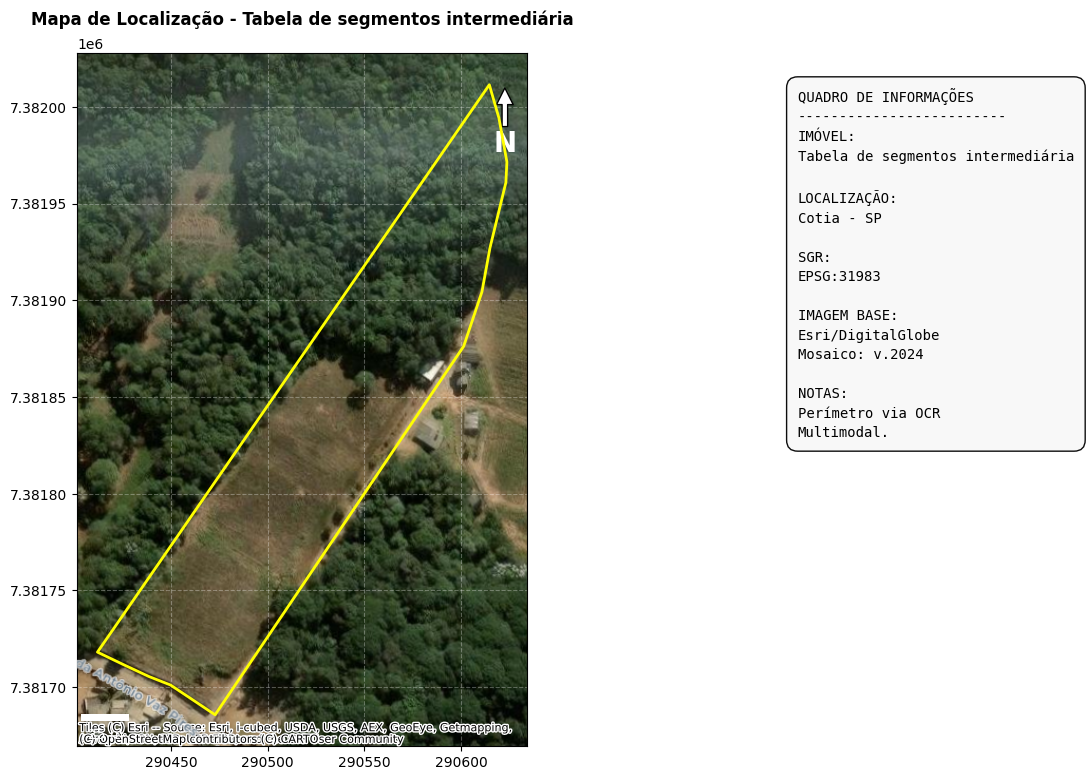

In [ ]:
gerar_mapa_profissional(coords, "EPSG:31983", "Tabela de segmentos intermediária")
